In [ ]:
# --- Arranque del entorno local (en Google Colab no cambia nada) ---
import pathlib
import sys
import types

try:
    _raiz = next(
        d
        for d in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
        if (d / "curso_setup.py").exists()
    )
    sys.path.insert(0, str(_raiz))
    import curso_setup
except StopIteration:  # Google Colab: se usa un sustituto mínimo
    import subprocess

    def _clonar(destino="curso_IA_CHEC"):
        if not pathlib.Path(destino).is_dir():
            subprocess.run(
                ["git", "clone", "https://github.com/UN-GCPDS/curso_IA_CHEC.git", destino],
                check=True,
            )
        return pathlib.Path(destino)

    def _descargar(file_id, destino):
        if not pathlib.Path(destino).exists():
            import gdown

            gdown.download(id=file_id, output=destino, quiet=False)
        return pathlib.Path(destino)

    curso_setup = types.SimpleNamespace(
        en_colab=lambda: True,
        init=lambda *a, **k: pathlib.Path.cwd(),
        clonar_curso=_clonar,
        descargar_drive=_descargar,
    )

curso_setup.init()

In [1]:
from sklearn.datasets import load_digits
digits= load_digits()


In [2]:
digits.data.shape, digits.target.shape

((1797, 64), (1797,))

In [3]:
X= digits.data
y= digits.target

In [4]:
X_new=X.reshape(-1,8,8)

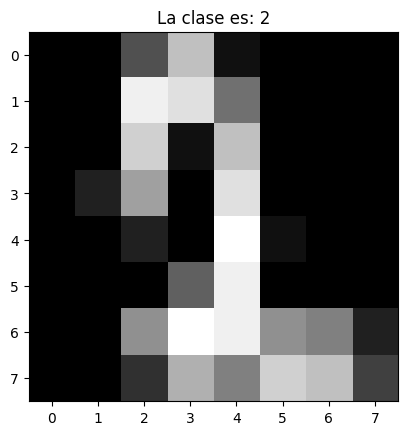

In [5]:
import matplotlib.pyplot as plt
plt.imshow(X_new[12],cmap='gray')
plt.title(f'La clase es: {y[12]}')
plt.show()

In [6]:
from sklearn.decomposition import PCA
pca= PCA(n_components=2)
X_pca= pca.fit_transform(X)
X.shape, X_pca.shape

((1797, 64), (1797, 2))

In [7]:
from sklearn.cluster import KMeans,DBSCAN,SpectralClustering
kmeans= KMeans(n_clusters=10)
kmeans.fit(X)
labels_kmeans= kmeans.predict(X)
dbscan = DBSCAN(eps=0.9, min_samples=5)
#dbscan.fit(X_pca)
labels_dbscan= dbscan.fit_predict(X)
spectral= SpectralClustering(n_clusters=10,gamma=0.1,affinity='nearest_neighbors')
spectral.fit(X_pca)
labels_spectral = spectral.fit_predict(X)

In [ ]:
fig, axes= plt.subplots(1,4,figsize=(15,5))
axes[0].scatter(X_pca[:,0],X_pca[:,1],c=y)
axes[0].set_title('Real')
axes[1].scatter(X_pca[:,0],X_pca[:,1],c=labels_kmeans)
axes[1].set_title('KMeans')
axes[2].scatter(X_pca[:,0],X_pca[:,1],c=labels_dbscan)
axes[2].set_title('DBSCAN')
axes[3].scatter(X_pca[:,0],X_pca[:,1],c=labels_spectral)
axes[3].set_title('Spectral')


Text(0.5, 1.0, 'Spectral')

In [ ]:
from sklearn.manifold import TSNE
tsne= TSNE(n_components=2,perplexity=30)
X_pca=tsne.fit_transform(X)

In [ ]:
from sklearn.cluster import KMeans,DBSCAN,SpectralClustering
kmeans= KMeans(n_clusters=10)
kmeans.fit(X)
labels_kmeans= kmeans.predict(X)
dbscan = DBSCAN(eps=0.9, min_samples=5)
#dbscan.fit(X_pca)
labels_dbscan= dbscan.fit_predict(X)
spectral= SpectralClustering(n_clusters=10,affinity='nearest_neighbors')
#spectral.fit(X_pca)
labels_spectral = spectral.fit_predict(X)

In [ ]:
fig, axes= plt.subplots(1,4,figsize=(15,5))
axes[0].scatter(X_pca[:,0],X_pca[:,1],c=y)
axes[0].set_title('Real')
axes[1].scatter(X_pca[:,0],X_pca[:,1],c=labels_kmeans)
axes[1].set_title('KMeans')
axes[2].scatter(X_pca[:,0],X_pca[:,1],c=labels_dbscan)
axes[2].set_title('DBSCAN')
axes[3].scatter(X_pca[:,0],X_pca[:,1],c=labels_spectral)
axes[3].set_title('Spectral')
# plt.scatter(X_pca[:,0],X_pca[:,1],c=labels_kmeans)
# plt.show()

In [ ]:
if curso_setup.en_colab():
    !pip install umap-learn

In [ ]:
import umap

In [ ]:
umap_model=umap.UMAP(n_components=2)
X_pca=umap_model.fit_transform(X)

In [ ]:
from sklearn.cluster import KMeans,DBSCAN,SpectralClustering
kmeans= KMeans(n_clusters=10)
kmeans.fit(X)
labels_kmeans= kmeans.predict(X)
dbscan = DBSCAN(eps=0.9, min_samples=5)
#dbscan.fit(X_pca)
labels_dbscan= dbscan.fit_predict(X)
spectral= SpectralClustering(n_clusters=10,affinity='nearest_neighbors')
#spectral.fit(X_pca)
labels_spectral = spectral.fit_predict(X)

In [ ]:
fig, axes= plt.subplots(1,4,figsize=(15,5))
axes[0].scatter(X_pca[:,0],X_pca[:,1],c=y)
axes[0].set_title('Real')
axes[1].scatter(X_pca[:,0],X_pca[:,1],c=labels_kmeans)
axes[1].set_title('KMeans')
axes[2].scatter(X_pca[:,0],X_pca[:,1],c=labels_dbscan)
axes[2].set_title('DBSCAN')
axes[3].scatter(X_pca[:,0],X_pca[:,1],c=labels_spectral)
axes[3].set_title('Spectral')
# plt.scatter(X_pca[:,0],X_pca[:,1],c=labels_kmeans)
# plt.show()

In [1]:
import numpy as np
from tensorflow.keras.datasets import mnist
(X_train,y_train),(X_test,y_test)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
plt.imshow(X_train[0],cmap='gray')
plt.show()

In [ ]:
if curso_setup.en_colab():
    !pip install openTSNE

In [2]:
X_train=X_train.reshape(-1,28*28).astype(np.float32)/255.0
X_test=X_test.reshape(-1,28*28).astype(np.float32)/255.0

In [ ]:
from openTSNE import TSNE

In [ ]:
tsne = TSNE(
    perplexity=30,
    metric="euclidean",
    n_jobs=8,
    random_state=42,
    verbose=True,
)

In [ ]:
embedding_train = tsne.fit(X_train)

In [ ]:
embedding_train.shape

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(embedding_train[:,0],embedding_train[:,1],c=y_train)#c=y_train
plt.show()

(60000, 784)

In [13]:
import cuml
from cuml.manifold.umap import UMAP as cuUMAP
cuumap = cuUMAP(n_components=2,             # The dimension of the space to embed into.
                n_neighbors=10,             # The size of local neighborhood (from 1 to 100)
                #local_connectivity=1,       # rho
                random_state=42,
                #n_epochs=100,               # The number of iterations to run
                #learning_rate=0.01          # The learning rate
                )
Z_train = cuumap.fit_transform(X_train)

[2026-02-13 05:20:19.769] [CUML] [info] build_algo set to brute_force_knn because random_state is given
